In [1]:
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src" / "ml_textbook").exists():
        sys.path.insert(0, str(_p / "src"))
        break

# 08. 時系列の機械学習 — 時間順を壊さない検証

> 各章は **直感 → 最小限の数式 → scikit-learn 実装 → 可視化 → 実験 → 演習** の順。本文は日本語、コードは英語、数式に日本語を入れない。

## この章で分かること

- 時系列が普通の表データと違う理由(**時間順序**と独立同分布でないこと)
- **ランダム交差検証が時系列では間違いになる**こと(未来のリーク)
- **ラグ特徴 / ローリング特徴** の作り方
- **TimeSeriesSplit** と **ウォークフォワード検証(バックテスト)**
- **予測ホライズン**が伸びると誤差が増えること、**レジームシフト**でモデルが劣化すること

> この章の主張: **「時系列にランダム交差検証を使うと、未来を見て学習してしまう」。**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "plotly_mimetype+notebook_connected"

from ml_textbook import datasets, plotting, widgets, validation

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
print("setup ok")

setup ok


## 1. 時系列はなぜ違うのか

通常の教師あり学習は、行が **独立同分布** だと仮定して自由にシャッフルします。時系列は違います:

- 観測は **時間順** に並び、隣同士が相関する
- 予測時に使えるのは **過去だけ**。未来は手に入らない
- 傾向(トレンド)や季節性で **分布が時間変化** する(非定常)

まずトレンド + 季節性のある系列を見ます。

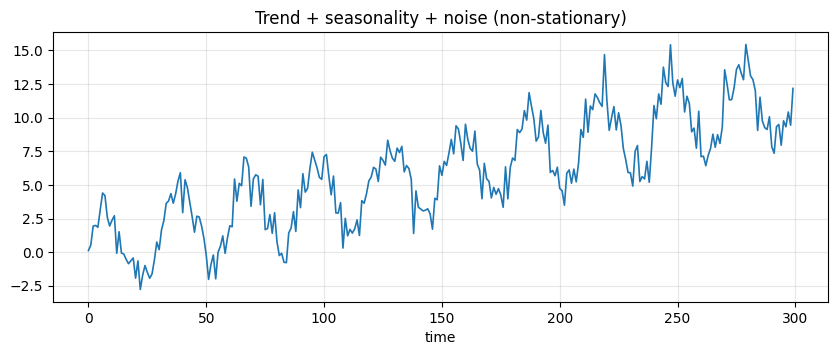

In [3]:
t, y = datasets.make_time_series_trend_seasonality(n=300, slope=0.04, period=30, seasonal_amp=3.0, noise=1.0, seed=0)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t, y, lw=1.2, color="#1f77b4")
ax.set_title("Trend + seasonality + noise (non-stationary)"); ax.set_xlabel("time"); ax.grid(alpha=0.3)
plt.show()

## 2. ランダム分割 vs 時間分割

ランダムに分割すると、テスト点が **過去と未来の訓練点に挟まれます**。モデルは未来を覗いて補間できてしまい、
本番(常に過去から未来を予測)より楽な問題を解くことになります。**TimeSeriesSplit** は訓練を必ず過去に保ちます。

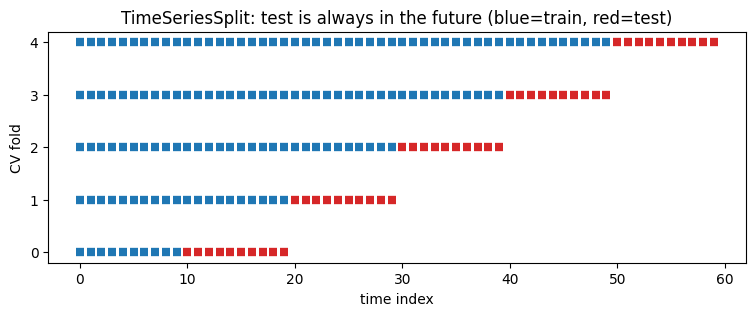

In [4]:
fig, ax = plt.subplots(figsize=(9, 3))
plotting.plot_time_series_split(60, n_splits=5, ax=ax)
plt.show()

### リークの実演 — 同じモデル・同じデータ、CV の組み方だけ違う

時刻インデックスから $y$ を予測する Random Forest を、(1) ランダム CV と (2) 時系列 CV で評価します。
ランダム CV は **補間** なので楽勝に見え、時系列 CV は **外挿** なので正直な(低い)スコアになります。
木は外挿できないので、未来予測の難しさが如実に出ます。

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score

X_time = t.reshape(-1, 1).astype(float)
rf = RandomForestRegressor(n_estimators=200, random_state=0)
random_cv = cross_val_score(rf, X_time, y, cv=KFold(5, shuffle=True, random_state=0), scoring="r2")
ts_cv = cross_val_score(rf, X_time, y, cv=TimeSeriesSplit(5), scoring="r2")
print(f"random  KFold     R2 = {random_cv.mean():.3f}   <- looks great (it is interpolating!)")
print(f"TimeSeriesSplit   R2 = {ts_cv.mean():.3f}   <- the honest score for forecasting")

random  KFold     R2 = 0.896   <- looks great (it is interpolating!)
TimeSeriesSplit   R2 = -0.539   <- the honest score for forecasting


## 3. ラグ特徴とローリング特徴

時系列を「教師あり学習」に落とすには、過去の値を特徴にします。

- **ラグ特徴**: $y_{t-1}, y_{t-2}, \dots$
- **ローリング特徴**: 直近 $w$ 点の移動平均・移動標準偏差

重要: ローリングは **必ず過去だけ**(`shift(1)` を噛ませる)で計算する。現在値を含めるとリーク。

In [6]:
def make_lag_features(series, n_lags=5, roll=10):
    df = pd.DataFrame({"y": np.asarray(series, float)})
    for L in range(1, n_lags + 1):
        df[f"lag_{L}"] = df["y"].shift(L)
    # shift(1) first => the window uses only strictly-past values (no leakage).
    df[f"roll_mean_{roll}"] = df["y"].shift(1).rolling(roll).mean()
    df[f"roll_std_{roll}"] = df["y"].shift(1).rolling(roll).std()
    return df.dropna().reset_index(drop=True)

ys = datasets.make_noisy_sine_series(n=400, periods=6, noise=0.2, seed=0)[1]
feat = make_lag_features(ys, n_lags=5, roll=10)
print(feat.head(3).round(3).to_string(index=False))
print("\nfeature columns:", [c for c in feat.columns if c != "y"])

    y  lag_1  lag_2  lag_3  lag_4  lag_5  roll_mean_10  roll_std_10
0.686  0.498  0.545  0.804  0.798  0.527         0.414        0.269
0.870  0.686  0.498  0.545  0.804  0.798         0.480        0.243
0.441  0.870  0.686  0.498  0.545  0.804         0.561        0.223

feature columns: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'roll_mean_10', 'roll_std_10']


## 4. ベースラインとモデルをウォークフォワードで比べる

予測は必ず **ベースライン** と比べます。素朴な「直前の値をそのまま」(naive)に勝てないモデルは無意味です。
**ウォークフォワード検証**(過去で学習→次を予測→窓を進める)で、線形回帰と Random Forest を比較します。

In [7]:
from sklearn.linear_model import LinearRegression

target = feat["y"].to_numpy()
Xf = feat.drop(columns="y").to_numpy()

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

# Naive baseline: predict y_t = y_{t-1} (the lag_1 column).
naive_rmse = rmse(target, feat["lag_1"].to_numpy())

results = {"naive (last value)": naive_rmse}
for name, model in [("linear", LinearRegression()), ("random forest", RandomForestRegressor(n_estimators=200, random_state=0))]:
    fold_rmse = [r["score"] for r in validation.walk_forward_validation(
        model, Xf, target, initial=200, horizon=20, expanding=True, metric=rmse)]
    results[name] = float(np.mean(fold_rmse))

for name, r in results.items():
    print(f"{name:20s} walk-forward RMSE = {r:.3f}")

naive (last value)   walk-forward RMSE = 0.292
linear               walk-forward RMSE = 0.251
random forest        walk-forward RMSE = 0.269


## 5. 予測ホライズン — 先を見るほど難しい

1 ステップ先は当てやすく、遠い未来ほど誤差が累積します。直近の窓から学習したモデルで **再帰的に**
先を予測し、ホライズンを伸ばすと予測が実測から離れていく様子をスライダーで見ます(静的 HTML 可)。

In [8]:
n_lags = 5
split = 300
train = make_lag_features(ys[:split], n_lags=n_lags, roll=10)
model = RandomForestRegressor(n_estimators=300, random_state=0).fit(
    train.drop(columns="y").to_numpy(), train["y"].to_numpy())

def recursive_forecast(model, history, n_lags, roll, steps):
    hist = list(history)
    preds = []
    for _ in range(steps):
        lags = hist[-n_lags:][::-1]
        rmean = np.mean(hist[-roll:]); rstd = np.std(hist[-roll:])
        x = np.array(lags + [rmean, rstd])[None, :]
        p = float(model.predict(x)[0]); preds.append(p); hist.append(p)
    return np.array(preds)

horizon = len(ys) - split
fc = recursive_forecast(model, ys[:split], n_lags, 10, horizon)
shown = [5, 15, 30, 50, 70, horizon]

frames = []
for k in shown:
    err = rmse(ys[split:split + k], fc[:k])
    frames.append(go.Frame(name=str(k), data=[
        go.Scatter(x=list(range(len(ys))), y=list(ys), mode="lines", line={"color": "#1f77b4"}, name="actual"),
        go.Scatter(x=list(range(split, split + k)), y=list(fc[:k]), mode="lines",
                   line={"color": "#d62728", "dash": "dash"}, name="forecast"),
    ], layout={"title": f"forecast {k} steps ahead   RMSE={err:.2f}"}))
fig = go.Figure(data=frames[0].data, frames=frames)
fig.add_vline(x=split, line_dash="dot", line_color="gray")
steps_ui = [{"args": [[f.name], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
             "label": f.name, "method": "animate"} for f in frames]
fig.update_layout(sliders=[{"steps": steps_ui, "currentvalue": {"prefix": "horizon = "}}],
                  title=frames[0].layout.title.text, width=820, height=420,
                  xaxis_title="time", yaxis_title="y", margin={"l": 50, "r": 20, "t": 60, "b": 40})
fig.show()

### インタラクティブ(JupyterLab のみ): ローリング検証の窓数

`TimeSeriesSplit` の分割数を変えて、訓練/テストの窓の進み方を確認します。

In [9]:
widgets.rolling_validation_explorer(n_samples=120)

interactive(children=(IntSlider(value=5, description='splits', max=8, min=2), Output()), _dom_classes=('widget…

<function ml_textbook.widgets.rolling_validation_explorer.<locals>.draw(n_splits)>

## 6. レジームシフト — 学習時と本番で世界が変わる

系列の生成規則が途中で変わると(レジームシフト)、過去で学習したモデルは急に外します。
レジーム 0 の区間だけで学習したモデルが、切り替わり後に劣化する様子を見ます。

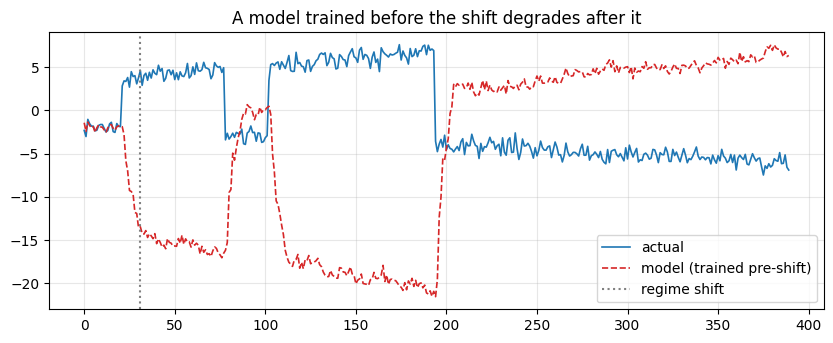

RMSE before shift = 7.11
RMSE after  shift = 16.06


In [10]:
yr, regime = datasets.make_regime_switching_series(n=400, switch_prob=0.0, noise=0.6, seed=1)
# Force a single clean switch at t=200 for a clear illustration.
yr, regime = datasets.make_regime_switching_series(n=400, switch_prob=0.004, noise=0.6, seed=5)
switch = int(np.argmax(regime != regime[0])) if (regime != regime[0]).any() else 200

feat_r = make_lag_features(yr, n_lags=5, roll=10)
cut = max(0, switch - 15)   # train only before the regime change
tr = feat_r.index < cut
lin = LinearRegression().fit(feat_r.drop(columns="y")[tr], feat_r["y"][tr])
pred_all = lin.predict(feat_r.drop(columns="y"))

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(feat_r.index, feat_r["y"], lw=1.2, label="actual", color="#1f77b4")
ax.plot(feat_r.index, pred_all, lw=1.2, ls="--", label="model (trained pre-shift)", color="#d62728")
ax.axvline(switch, color="gray", ls=":", label="regime shift")
ax.set_title("A model trained before the shift degrades after it"); ax.legend(); ax.grid(alpha=0.3)
plt.show()
print(f"RMSE before shift = {rmse(feat_r['y'][feat_r.index < switch], pred_all[feat_r.index < switch]):.2f}")
print(f"RMSE after  shift = {rmse(feat_r['y'][feat_r.index >= switch], pred_all[feat_r.index >= switch]):.2f}")

## 7. まとめ

- 時系列は **時間順** と **非定常性** のため、行を自由にシャッフルできない。
- **ランダム交差検証は未来をリーク**して楽観的になる。**TimeSeriesSplit / ウォークフォワード**を使う。
- 特徴は **ラグ・ローリング**。ローリングは `shift(1)` で過去だけにする。
- 予測は必ず **naive ベースライン** と比較。勝てて初めて意味がある。
- ホライズンが伸びると誤差は累積。**レジームシフト**でモデルは劣化するので **再学習・監視**(10 章)が要る。

## 8. Exercises

1. ランダム CV vs TimeSeriesSplit の R2 差を、トレンドの傾き `slope` を 0 にすると小さくなるか確かめよ。
2. ラグ数 `n_lags` を 1 / 5 / 20 と変え、線形回帰のウォークフォワード RMSE がどう動くか調べよ。
3. naive ベースラインに勝てないモデル設定(特徴が乏しい等)を作ってみよ。
4. 予測ホライズンのスライダーで、`noise` を 0.05 と 0.5 にして誤差の増え方を比べよ。
5. (発展)レジームシフト後のデータも訓練に含めると RMSE がどれだけ回復するか測れ。

## 9. Common Mistakes

- **時系列にランダム CV / `shuffle=True`。** 未来リーク。時間順を保つ分割を使う。
- **ローリング特徴に現在値を含める。** リーク。`shift(1)` を忘れない。
- **ベースラインと比べない。** naive に負けるモデルを「良い」と誤認する。
- **一度学習して放置。** レジームシフトで劣化。再学習とドリフト監視(10 章)。

## 10. Advanced Notes

**定常性。** 多くの時系列手法は(弱)定常 — 平均・分散・自己相関が時間によらない — を仮定する。
トレンドや季節性があると非定常なので、**差分**(`y_t - y_{t-1}`)や季節差分で定常化してから扱うことが多い。
本章の機械学習アプローチ(ラグ特徴 + 木/線形)は、定常化を明示せずとも特徴で吸収できるのが利点。